# editing plots

In [ ]:
python /work/jessica.mcdonald/CM1_LETKF_2025/ens.py -e RUN_LETKF/RUN_LETKF.exp -t 2003,05,08,21,40,00 -v W --plotmean

In [1]:
import sys
sys.path.append('src/')
#import computeHx
import ens_test

ModuleNotFoundError: No module named 'ens_test'

In [1]:
from optparse import OptionParser
import sys
import os
import numpy as np
import datetime as DT 
import netCDF4 as ncdf
import glob
import pylab as P
from datetime import datetime
from src.plot_src.cbook2 import nice_mxmnintvl, nice_clevels
import matplotlib.cm as cm
import matplotlib.ticker as ticker
import matplotlib.dates as mdates
from scipy import ndimage


from matplotlib.colors import LinearSegmentedColormap, to_rgb

_bin_delta = 1
radar_hgt = 0

_prior_files = "Prior_*"
_plotfilename = "DBZ_ConsistencyRatio"

sec_utime = "seconds since 1970-01-01 00:00:00"


## settings for plots - makes them look nicer
import matplotlib as mpl
import matplotlib.pyplot as plt
plt.rc('xtick', labelsize=14) 
plt.rc('ytick', labelsize=14) 
plt.rc('axes', labelsize=14, titlesize=18) 
mpl.rcParams.update({"axes.grid" : False, "grid.color": "0.6",  'grid.linestyle':':',
                    'grid.linewidth':1, 'axes.labelweight':'bold', 'legend.framealpha':1.0})


In [2]:
def smfnc(x):
    return ndimage.gaussian_filter(x, sigma=0.75)
    
# ------------------------------------------------------------------------------------------
# Search functions  each returns a boolean array of T/F with the same dimensions as field

def getIndexVariable(field, variable):
    return (field == variable)
    
def getIndexGreaterThan(field, value):
    return ( field > value )
    
def getIndexLessThan(field, value):
    return ( field < value )
    
def getIndexGreaterThanOrEqual(field, value):
    return ( field >= value )
    
def getIndexLessThanOrEqual(field, value):
    return ( field <= value )

def getIndexEqual(field, value):
    return ( field == value )

def getIndexNotEqual(field, value):
    return ( field != value )

def get_stats_timeseries(experiment_location, only_pos_dbz=True, variable='REF', full_field=False, dz=2000):
    '''experiment_location = path to the .exp file
       only_pos_dbz = if True, then only >10 dBZ is inluded in calculations (innovations will still include all data)
       variable = REFL or DBZ 
       full_field = if True, returns 2d field (x=time, y=height).
       dz is the size of the vertical bins'''

    if variable !='REF':
        only_pos_dbz=False
    
    dirname = os.path.join(experiment_location,_prior_files)
    #plotfilename='DBZ_CR'
    #noshow=True

    file_list = glob.glob(dirname)
    file_list = sorted(file_list,key=os.path.getmtime)

    bin_delta = _bin_delta

    nbins     = len(file_list) // bin_delta
    CR_T      = np.zeros((nbins))
    IN_T      = np.zeros((nbins))
    RMSI_T    = np.zeros((nbins))
    Spread_T  = np.zeros((nbins))

    if full_field:
        print('RETURNING 2D FIELDS')
        zbins    = dz*np.arange(int(8000/dz))
        print(zbins)
        CR_T     = np.zeros((zbins.size,nbins))
        IN_T     = np.zeros((zbins.size,nbins))
        RMSI_T   = np.zeros((zbins.size,nbins))
        Spread_T = np.zeros((zbins.size,nbins))

    datebins = []
    secsbins = []
    m = -1

    for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))

            m+=1

            index_kind  = getIndexVariable(kind,variable)

            #### do a 1D timeseries for each variable
            if full_field == False: 
                if only_pos_dbz & ((variable=='REF')):
                    index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                    index       = index_kind & index_pos
                else:
                    index = index_kind
           
                if np.sum(index == True) > 2: 
                    
                    d           = dep[index] # innovation
                    obs_var     = error[index]
                    Hxftmp      = Hxf[index,:]
                    Hxf_var     = Hxftmp.var(ddof=1, axis=1).mean() 
                    inno_var    = np.mean((d - d.mean())**2) 
                    RMSI_T[m]   = np.mean(np.sqrt((d - d.mean())**2))
                    
                    Spread_T[m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                    CR_T[m]     = (obs_var[1]**2 + Hxf_var) / inno_var # same thing as total spread squared / RMSI sqared
    
                    # for now, calculate innovations WITHOUT a positive DBZ filter (if you're using DBZ)
                    if only_pos_dbz:
                        d        = dep[index_kind] # innovation
                        IN_T[m]  = d.mean()
                    else:
                        IN_T[m]  = d.mean()

            #### return 2D fields
            else:
                for k in np.arange(zbins.size-1):
                    index1                = getIndexGreaterThanOrEqual(z, zbins[k])
                    index2                = getIndexLessThan(z, zbins[k+1])
                    if only_pos_dbz & ((variable=='REF')):
                        index_pos   = getIndexGreaterThanOrEqual(value,10.0)
                        index             = index_kind & index1 & index2 & index_pos
                    else:
                        index             = index_kind & index1 & index2
        
                    if np.sum(index == True) > 2: 
                        d             = dep[index]
                        obs_var       = error[index]
                        Hxftmp        = Hxf[index,:]
                        Hxf_var       = Hxftmp.var(ddof=1, axis=1).mean()
                        inno_var      = np.mean((d - d.mean())**2)
                        CR_T[k,m]     = (obs_var[1]**2 + Hxf_var) / inno_var
                        RMSI_T[k,m]   = np.mean(np.sqrt((d - d.mean())**2))
                        Spread_T[k,m] = np.sqrt((obs_var[1]**2 + Hxf_var))
                        if only_pos_dbz:
                            d         = dep[index_kind & index1 & index2] # innovation
                            IN_T[k,m] = d.mean()
                        else:
                            IN_T[k,m] = d.mean()
                            
        f.close()

    if full_field:
        datebins = [datebins, zbins]

    return datebins, CR_T, IN_T, Spread_T, RMSI_T


def format_time_ticks(ax, dates, minute_interval=10, approx_number_of_ticks=8,  tick_format='%H:%M', rotation=30, fontsize=14):
    ''' This does basic formatting to help clean up the plot cells'''

    start = dates[0].replace(second=0, microsecond=0)
    end   = dates[-1].replace(second=0, microsecond=0)
    ax.set_xlim(start, end)
    minute_interval = 5*round((end-start).seconds/(approx_number_of_ticks*60*5)) #find the best interval divisble by 5 based on nticks
    maj_loc = mdates.MinuteLocator(interval=minute_interval)
    ax.xaxis.set_major_locator(maj_loc)
    dateFmt = mdates.DateFormatter(tick_format)
    ax.xaxis.set_major_formatter(dateFmt)
    labels = ax.get_xticklabels()
    plt.setp(labels, rotation=30, fontsize=fontsize)


def CR_cmap():
    col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
    col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
    col1.extend(col2)
    clist = [to_rgb(c) for c in col1[::-1]]
    i1,i2 = 9,11
    clist[i1:i2] = np.array(clist[i1:i2])*1.18
    cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
    return cmap

In [7]:
import xarray as xr
f = xr.open_dataset(file_list[0])


In [12]:
np.unique(f.type)

array([b'', b'REF', b'VR'], dtype='|S8')

In [5]:
experiment_location='/scratch/home/jessica.mcdonald/LETKF_runs/DBZ_VR'
experiment_location = '/work/jessica.mcdonald/CM1_LETKF_2025/test'

dirname = os.path.join(exps[0],_prior_files)
plotfilename='DBZ_CR'
noshow=True

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

/tmp/ipykernel_2027532/2091818686.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
/tmp/ipykernel_2027532/2091818686.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
/tmp/ipykernel_2027532/2091818686.py:31: RuntimeWarning: Mean of empty slice
  inno = np.nanmean((d),axis=1) ##identical
/tmp/ipykernel_2027532/2091818686.py:34: RuntimeWarning: Mean of empty slice
  inno_post = np.nanmean((d_post),axis=1)
/tmp/ipykernel_2027532/2091818686.py:37: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
/tmp/ipykernel_2027532/2091818686.py:37: RuntimeWarning: Mean of empty slice
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
/tmp/ipykernel_2027532/2091818686.py:38: RuntimeWarning: Mean of empty slice
  inno_var = np.nanmean((d-np.nanm

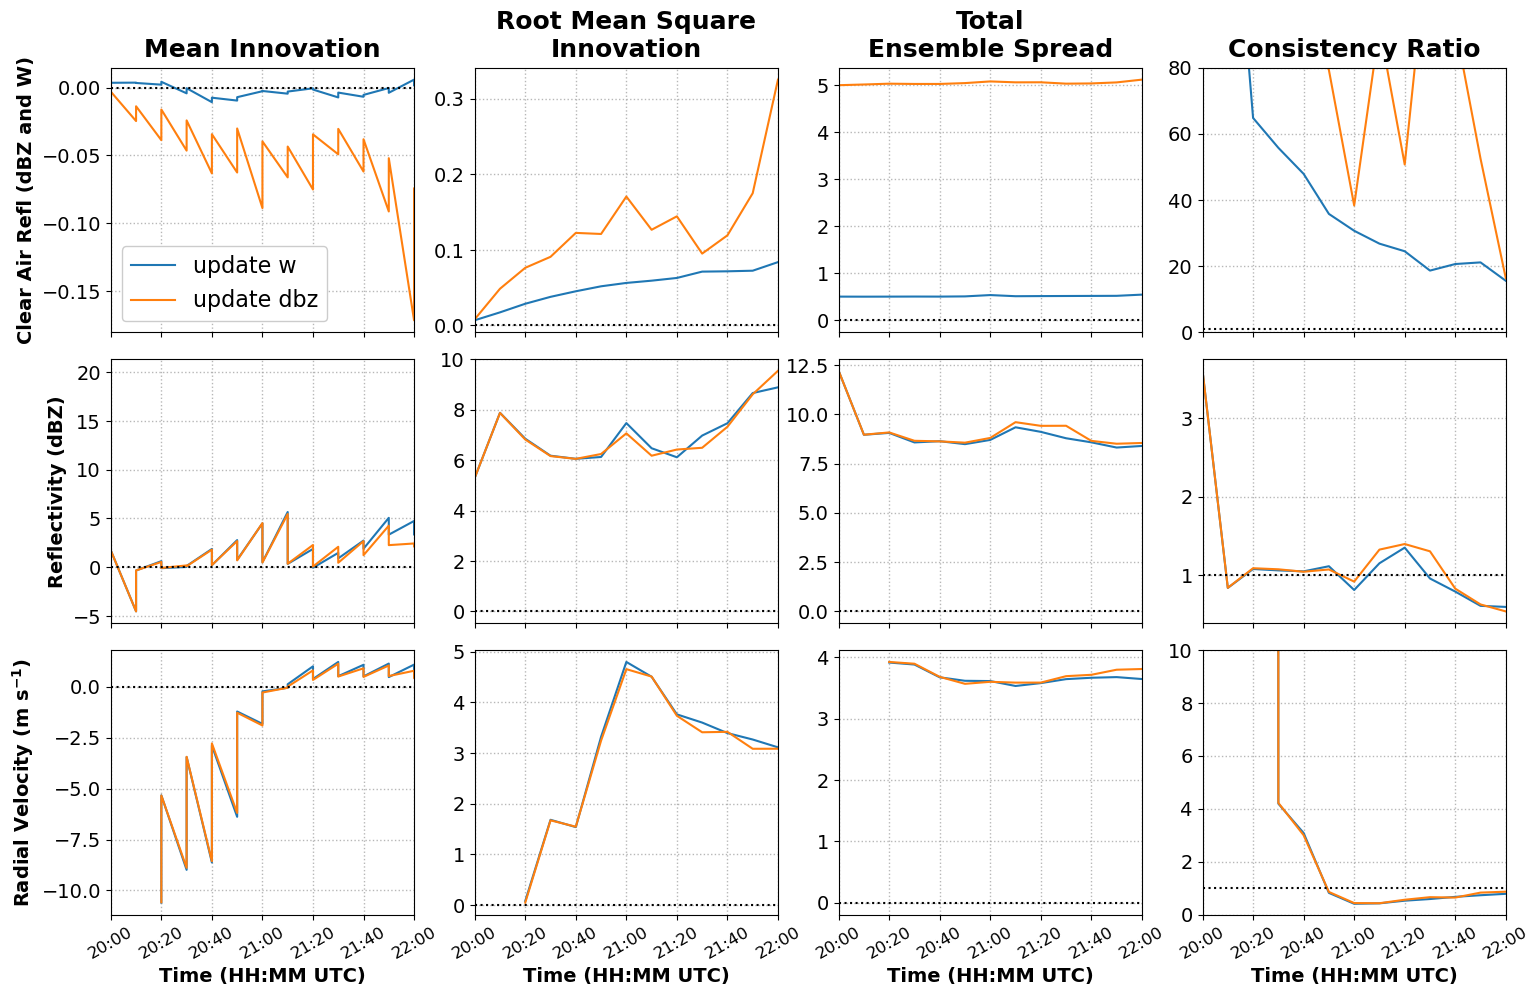

In [327]:
labels = [ 'update w', 'update dbz']

exps = ['/work/jessica.mcdonald/CM1_LETKF_2025/test','/work/jessica.mcdonald/CM1_LETKF_2025/test_outliers',
        '/work/jessica.mcdonald/CM1_LETKF_2025/test_w']


exps = ['/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w','/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_0']
obs = [ 'DBZ0_W', 'DBZ', 'VR']

fig,axes = plt.subplots(3,4, figsize=(18,11), sharex=True)


axes[0,0].set_title('Mean Innovation', weight='bold', y=1.01)
axes[0,1].set_title('Root Mean Square\nInnovation', weight='bold', y=1.01)
axes[0,2].set_title('Total\nEnsemble Spread', weight='bold', y=1.01)
axes[0,3].set_title('Consistency Ratio', weight='bold', y=1.01)

max_CR=[]

for i,exp in enumerate(exps):
    if i == 0: obs = [ 'DBZ0_W', 'DBZ', 'VR']
    else: obs = [ 'DBZ0', 'DBZ', 'VR']
        

    for ii,var in enumerate(obs):
        
        

        #dates, CR, IN, SPRD, RMSI = get_stats_timeseries(exp, only_pos_dbz=False, variable=var)

        dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
        max_CR.append(np.max(CR))
        axes[ii,0].plot(dates_n, IN,   label=labels[i])
        axes[ii,1].plot(dates, RMSI, label=labels[i])
        axes[ii,2].plot(dates, SPRD, label=labels[i])
        axes[ii,3].plot(dates, CR,   label=labels[i])

# formatting
plt.subplots_adjust(hspace=0.1)
for ax in axes[-1,:].flatten():
    format_time_ticks(ax, dates, fontsize=12, approx_number_of_ticks=6)
    ax.set_xlabel('Time (HH:MM UTC)')
for ax in axes.flatten():
    ax.grid(ls=':', alpha=0.7)
for ax in axes[:,[0,1,2]].flatten():
    ax.axhline(0, ls=':', color='k')
for ax in axes[:,3].flatten():
    ax.axhline(1, ls=':', color='k')


axes[0,3].set_ylim(0, 80)
axes[2,3].set_ylim(0, 10)

# if "DBZ0_W" in obs:
#     axes[0,0].set_ylabel('Clear Air Refl (dBZ->W)', weight='bold');
# else:
#     axes[0,0].set_ylabel('Clear Air Refl (dBZ)', weight='bold');

axes[0,0].legend(loc=3, fontsize=16)


axes[0,0].set_ylabel('Clear Air Refl (dBZ and W)', weight='bold');
    
axes[1,0].set_ylabel('Reflectivity (dBZ)', weight='bold');
axes[2,0].set_ylabel(r'Radial Velocity (m s$\mathbf{^{-1}}$)', weight='bold');

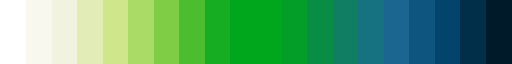

In [156]:
colors = ['#f7f7f7','#ededeb','#cbe681', '#71c93a',   '#00a61c', \
          '#40bcc7',  '#86d9f0', '#def5fc','#f7f7f7']

colors = ['#ffffff','#f2f2df','#cbe681', '#71c93a',   '#00a61c',  '#00a61c',\
          '#0d8259',  '#1e6996', '#044770','#001a29']

clist = [np.array(to_rgb(c))*1 for c in colors]
clist[4] = np.array(to_rgb('#00a61c'))
cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
cmap

In [170]:
for c in col1:
    print(c)

[1.         1.         0.89803922 1.        ]
[0.9812995  0.99298731 0.79518647 1.        ]
[0.94232987 0.97771626 0.70620531 1.        ]
[0.86851211 0.94818916 0.65207228 1.        ]
[0.76842753 0.90552864 0.59981546 1.        ]
[0.65642445 0.85711649 0.54814302 1.        ]
[0.52601307 0.80052288 0.49647059 1.        ]
[0.39277201 0.7382699  0.43489427 1.        ]
[0.25743945 0.67183391 0.36599769 1.        ]
[0.18246828 0.57642445 0.30193003 1.        ]
[array([0.18246828, 0.59784698, 0.34443676, 1.        ]), array([0.256609  , 0.68327566, 0.46486736, 1.        ]), array([0.3476509 , 0.7324875 , 0.57805459, 1.        ]), array([0.45333333, 0.78379085, 0.68183007, 1.        ]), array([0.57882353, 0.83792388, 0.77287197, 1.        ]), array([0.70431373, 0.88796617, 0.84755094, 1.        ]), array([0.81460977, 0.93074971, 0.91306421, 1.        ]), array([0.87612457, 0.95289504, 0.95981546, 1.        ]), array([0.92655133, 0.97187236, 0.98280661, 1.        ]), array([0.96862745, 0.98823

In [5]:
import cmocean

In [6]:
import cmasher as cmr

40
35
30
25
20


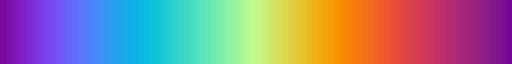

In [44]:
col = list(cmr.infinity(np.linspace(0, 1, 100)))

clist = [to_rgb(c) for c in col]
clist = [np.array(c)*1.3 for c in clist]

clist[0:50] = np.array(clist[0:50])*1.02

clist[0:45] = np.array(clist[0:45])*1.01
for i in np.arange(40, 15, -5):
    print(i)
    clist[0:i] = np.array(clist[0:i])*1.01
cmap = LinearSegmentedColormap.from_list("CR", clist, 100)
cmap

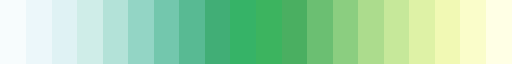

In [246]:
col1 = list(plt.cm.YlGn(np.linspace(0,.68, 10)))
col2 = list(plt.cm.BuGn(np.linspace(0,.7, 10))[::-1])
col1.extend(col2)
clist = [to_rgb(c) for c in col1[::-1]]
i1,i2 = 9,11
clist[i1:i2] = np.array(clist[i1:i2])*1.18
cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
#return cmap

#cmap = LinearSegmentedColormap.from_list("CR", clist, 20)
cmap

# combining Priors, making Posteriors

RETURNING 2D FIELDS
[   0 2000 4000 6000]
RETURNING 2D FIELDS
[   0 2000 4000 6000]


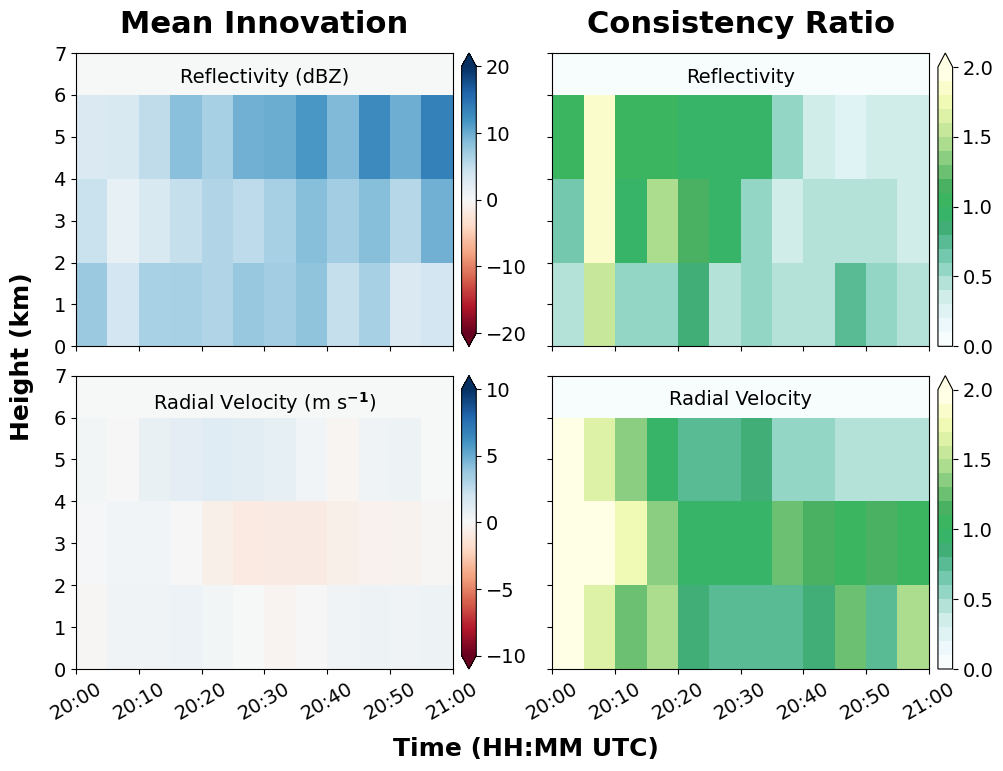

In [102]:
fig, axes = plt.subplots(2,2, figsize=(12,8), sharey=True, sharex=True)

vals = [20, 10]
fs = 14
cmap = CR_cmap()

for ii,var in enumerate(['REF', 'VR']): 
    TZ, CR, IN, SPRD, RMSI = get_stats_timeseries(experiment_location, only_pos_dbz=True, variable=var, full_field=True, dz=2000)
    t, z = list(TZ[0]), list(TZ[1]/1000)
    z.append(z[-1]+z[1]-z[0])
    t.append(t[-1]+(t[1]-t[0]))
    im1 = axes[ii,0].pcolormesh(t,z, IN, vmin=-1*vals[ii], vmax=vals[ii], cmap='RdBu')
    im2 = axes[ii,1].pcolormesh(t,z, CR, vmin=0, vmax=2, cmap=cmap)

    if ii ==1:format_time_ticks(axes[ii,0],t[:-1]);format_time_ticks(axes[ii,1],t[:-1])

    if ii==0: 
        axes[ii,0].text(0.5, .95, 'Reflectivity (dBZ)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Reflectivity',       ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    if ii==1: 
        axes[ii,0].text(0.5, .95, r'Radial Velocity (m s$\mathbf{^{-1}}$)', ha='center', va='top', transform=axes[ii,0].transAxes, fontsize=fs )
        axes[ii,1].text(0.5, .95, 'Radial Velocity',                        ha='center', va='top', transform=axes[ii,1].transAxes, fontsize=fs )

    plt.colorbar(im1, ax =axes[ii,0], pad=.02, extend='both')
    plt.colorbar(im2, ax =axes[ii,1], pad=.02, extend='max') 

axes[0,0].set_ylim(0,7)

plt.subplots_adjust(hspace=.1, wspace=0.05)

axes[0,0].set_title('Mean Innovation',   weight='bold',fontsize=22, y=1.04)
axes[0,1].set_title('Consistency Ratio', weight='bold',fontsize=22, y=1.04)

fig.text(0.5, 0.01, 'Time (HH:MM UTC)', ha='center', va='center', weight='bold', fontsize=18);
fig.text(0.07,0.5, 'Height (km)', weight='bold', va='center', fontsize=18, rotation='vertical');

In [6]:
import json
import xarray as xr
import datetime as dt
import pandas as pd

In [144]:
13*9798

127374

In [321]:
##### SAVING PRIORS

# prior
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_0'

file_version = 'Prior' 
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)

num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}

with open(f'{exp}/{os.path.basename(exp)}.exp', 'rb') as f: exper = json.load(f)
obs = exper['DA_PARAMS']['obs_included']
obnum = [obs2num[ob] for ob in obs]

ensN = exper['ne']
t    = len(file_list)
n = np.max([len(xr.open_dataset(file).ob_num) for file in file_list])
times = [datetime.strptime(os.path.basename(file).replace(file_version, ''), '_%Y-%m-%d_%H:%M:%S.nc') for file in file_list]


# step one - make the skeleton of dataset
coords = { 't': np.arange(0, t),'ne': np.arange(0,ensN),'n':  np.arange(0, n)}
myds = xr.Dataset( coords)
#print(myds.keys())


# fill with nan variables of proper size
f = xr.open_dataset(file_list[0])
for v in list(f.keys()):
    if v not in ['type', 'dates']:
        if len(np.shape(f[v])) == 1:
            myds[v] = (('t', 'n'), np.zeros([t, n])*np.nan)
        if len(np.shape(f[v])) == 2:
            myds[v] = (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
f.close()
            
# fill nan variables with actual data
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    for v in list(myds.keys()):
        myds[v][fi, :fn] = f[v].values
    f.close()

# add time var
myds['time'] =  (('t'), times) 

# add masks for different variables

fix_kinds = myds.kind.values
fix_kinds[np.isnan(fix_kinds)] = -999
myds['kind'] = (('t', 'n'), fix_kinds)
for ob in obs:
    myds[ob] = (('t', 'n'), myds['kind'].values == obs2num[ob])


##### now add in the posterior values!!
myds['Hxf_post']= (('t', 'n', 'ne'), np.zeros([t, n, ensN])*np.nan)
myds['Hxfbar_post']= (('t', 'n'), np.zeros([t, n])*np.nan)
myds['outlier_post']= (('t', 'n'), np.zeros([t, n])*np.nan)

file_version='Posterior'
dirname = os.path.join(exp,file_version+'*.nc')
file_list = sorted(glob.glob(dirname),key=os.path.getmtime)
for fi, file in enumerate(file_list):
    f = xr.open_dataset(file)
    fn = len(f.ob_num)
    #for v in list(myds.keys()):
    myds['Hxf_post'][fi, :fn] = f['Hxf'].values
    myds['Hxfbar_post'][fi, :fn] = f['Hxfbar'].values
    myds['outlier_post'][fi, :fn] = f['outlier'].values
    f.close()

savename = os.path.join(os.path.dirname(file_list[0]), f'AllPrior_Post.nc')
myds.to_netcdf(savename, format='NETCDF4')

In [313]:

num2obs = {11: ["VR"], 12:["DBZ"], 13:['DBZ0'], 14:['DBZ0_W']}
obs2num  = {'VR':11, 'DBZ':12, 'DBZ0':13, 'DBZ0_W':14}

def get_ds(myds, kind, t, mem=None):

    ''' this gets you all the data for single data type at a single time
        you cannot get the full dataset for multiple times and multiple variables'''

    kindID = obs2num[kind]
    ds = myds.copy()
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))

    ds = ds.isel(t=slice(t,t+1))
    
    ds = ds.isel(n=ds[kind].values[0])
    return ds
   


def get_var(myds, var, kind, t=None, tf=None, mem=None, keep_dim=True, drop_outliers=True):
    ''' returns a single variable. for a single data type. Keep_dim means you keep the time dimension.
        if t == None, whole dataset returned. if mem=None, all members returned (and dimensions are retained)
        if t!= None but tf == None, then only a single index (t) is returned. Else, a slice between t and tf is returned.'''

    ds = myds.copy()

    if drop_outliers:
        variable = ds[var].values
        variable[ds.outlier.values>3] = np.nan

        if ((var== 'Hxf') | (var== 'Hxf_post')):
            ds[var] = (('t', 'n', 'ne'), variable)
        else:
            ds[var] = (('t', 'n'), variable)
    
    if mem!= None:
        ds = ds.isel(ne=slice(mem,mem+1))
    
    if t!= None:
        if tf == None:tf = t+1
        ds = ds.isel(t=slice(t,tf))
    
    if len(ds.t)==1:
        ds = ds.isel(n=ds[kind].values[0])
        mydata = ds[var].values
        mydata = mydata[np.isnan(mydata) == False]
    
    if (len(ds.t)>1) & (keep_dim==False):
        mydata = ds[var].values[ds[kind].values]
        mydata = mydata[np.isnan(mydata) == False]
    
    
    if (len(ds.t)>1) & (keep_dim) & ((var!= 'Hxf') & (var!= 'Hxf_post')):  
        temp = []
        sizes = []
    
        mydata = np.zeros([len(ds.t), 100000])*np.nan
    
        for i in range(len(ds.t)):
           
            v = ds[var].values[i][ds[kind].values[i]]
            sizes.append(len(v))
            mydata[i, :len(v)] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
    
    if (len(ds.t)>1) & (keep_dim) & ((var== 'Hxf') | (var== 'Hxf_post')) :  
        temp = []
        sizes = []
    
        if mem !=None: mydata = np.zeros([len(ds.t), 100000])*np.nan
        else:  mydata = np.zeros([len(ds.t), 100000, len(ds.ne)])*np.nan
        for i in range(len(ds.t)):
            for n in range(len(ds.ne)):
                v = ds[var].values[i,:,n][ds[kind].values[i]]
                sizes.append(len(v))
                mydata[i, :len(v), n] = v
        
        mydata = mydata[:,:np.nanmax(sizes)]
        

    return np.array(mydata)
    


In [320]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
var = 'DBZ0_W'

#dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)



def get_stats_times(var, exp):

    
    ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)
    
    
    
    times = [pd.Timestamp(t) for t in ds.time.values]
    
    
    val = get_var(ds, 'value', var)
    
    Hxfbar = get_var(ds, 'Hxfbar', var)
    Hxf = get_var(ds, 'Hxf', var)
    
    Hxfbar_post = get_var(ds, 'Hxfbar_post', var)
    Hxf_post = get_var(ds, 'Hxf_post', var)
    
    obs_var = get_var(ds, 'error',var) ### NOTE - THIS IS ALREADY SQUARED!
    
    
    d = val - Hxfbar ## identical
    inno = np.nanmean((d),axis=1) ##identical
    
    d_post = val-Hxfbar_post
    inno_post = np.nanmean((d_post),axis=1) 
    
    
    Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical
    inno_var = np.nanmean((d-np.nanmean(d, axis=1)[:,np.newaxis])**2, axis=1) ## identical
    
    RMSI_n = np.nanmean(np.sqrt((d-np.nanmean(d, axis=1)[:,np.newaxis])**2), axis=1) ##identical
    spread = np.sqrt(np.nanmax(obs_var) + Hxf_var)
    crt = (np.nanmax(obs_var) + Hxf_var) / inno_var 

    new_inno = [None]*(len(times)*2)
    new_inno[::2] = inno
    new_inno[1::2] = inno_post
    
    new_time = [None]*(len(times)*2)
    new_time[::2] =times
    new_time[1::2] = times

    return times, new_time, new_inno, crt,spread, RMSI_n

In [318]:
dates,dates_n, IN, CR, SPRD, RMSI = get_stats_times(var, exp)
print(var, exp)

DBZ0_W /work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w


/tmp/ipykernel_2027532/2346624567.py:35: RuntimeWarning: Degrees of freedom <= 0 for slice.
  Hxf_var = np.nanmean(np.nanvar(Hxf, ddof=1, axis=2),axis=1) ##identical


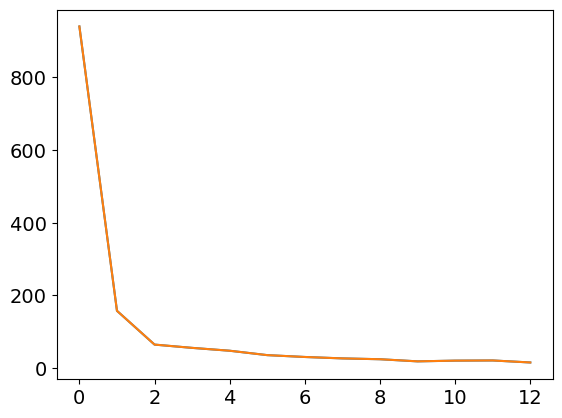

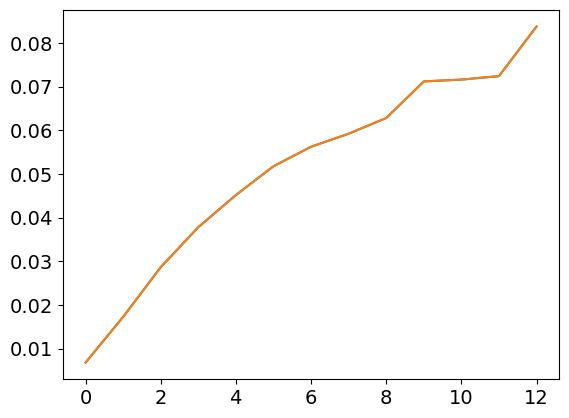

In [156]:
plt.figure()
plt.plot(crt)
plt.plot(CR)

plt.figure()
plt.plot(RMSI)
plt.plot(RMSI_n)

In [157]:
new_inno = [None]*(len(times)*2)
new_inno[::2] = inno
new_inno[1::2] = inno_post

new_time = [None]*(len(times)*2)
new_time[::2] =times
new_time[1::2] = times

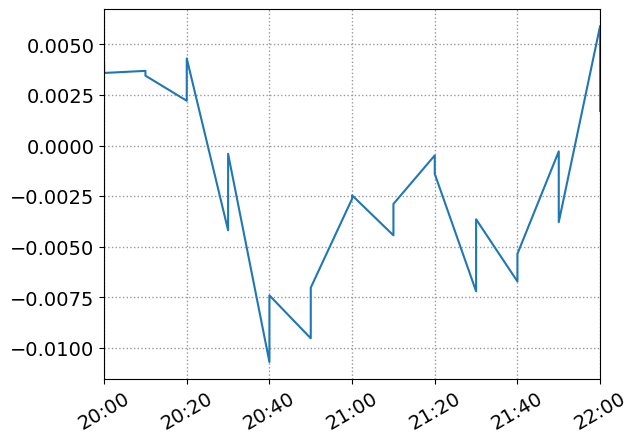

In [168]:
fig,ax = plt.subplots()
ax.plot(new_time, new_inno)
ax.grid()
format_time_ticks(ax,new_time, approx_number_of_ticks=6)

In [26]:


hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
hxf_vr = get_var(ds, 'Hxf', 'VR')

hxf_dbz_post = get_var(ds, 'Hxf_post', 'DBZ')
hxf_vr_post = get_var(ds, 'Hxf_post', 'VR')

outliers = get_var(ds, 'outlier', 'DBZ')
hxf_dbz[outliers > 3] = np.nan

In [24]:
np.shape(hxf_dbz)

hxf_dbz[outliers > 3] = np.nan

(13, 2426, 36)

In [25]:
np.shape(outliers)

(13, 2426)

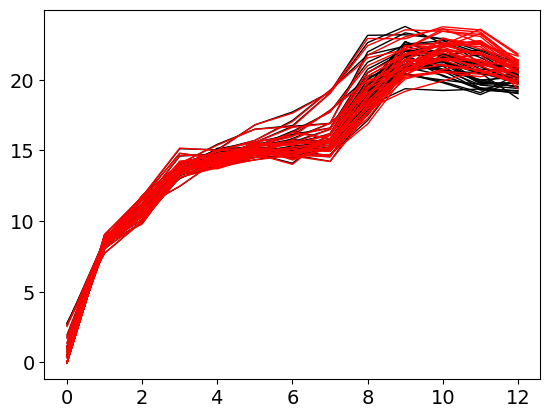

In [28]:

hxf_dbz = get_var(ds, 'Hxf', 'DBZ')
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='k');

hxf_dbz[outliers > 3] = np.nan
plt.plot(np.nanmean(hxf_dbz , axis=1), lw=1, color='r');
#plt.plot(np.nanmean(hxf_dbz_post[outliers<=3] , axis=1), lw=1, color='r');

In [227]:
pos1[0]

Timestamp('2024-05-08 20:03:00')

In [266]:
def draw_plot(ax,data, pos,edge_color, fill_color):
  
    bp = ax.boxplot(data, positions= pos, widths=0.3, patch_artist=True, sym='d')
    for element in ['boxes', 'whiskers', 'fliers', 'medians', 'caps']:
        plt.setp(bp[element], color=edge_color)
    for patch in bp['boxes']:
        patch.set(facecolor=fill_color)
    plt.setp(bp['fliers'], markersize=3.0)
    plt.setp(bp['fliers'], alpha=0.5)

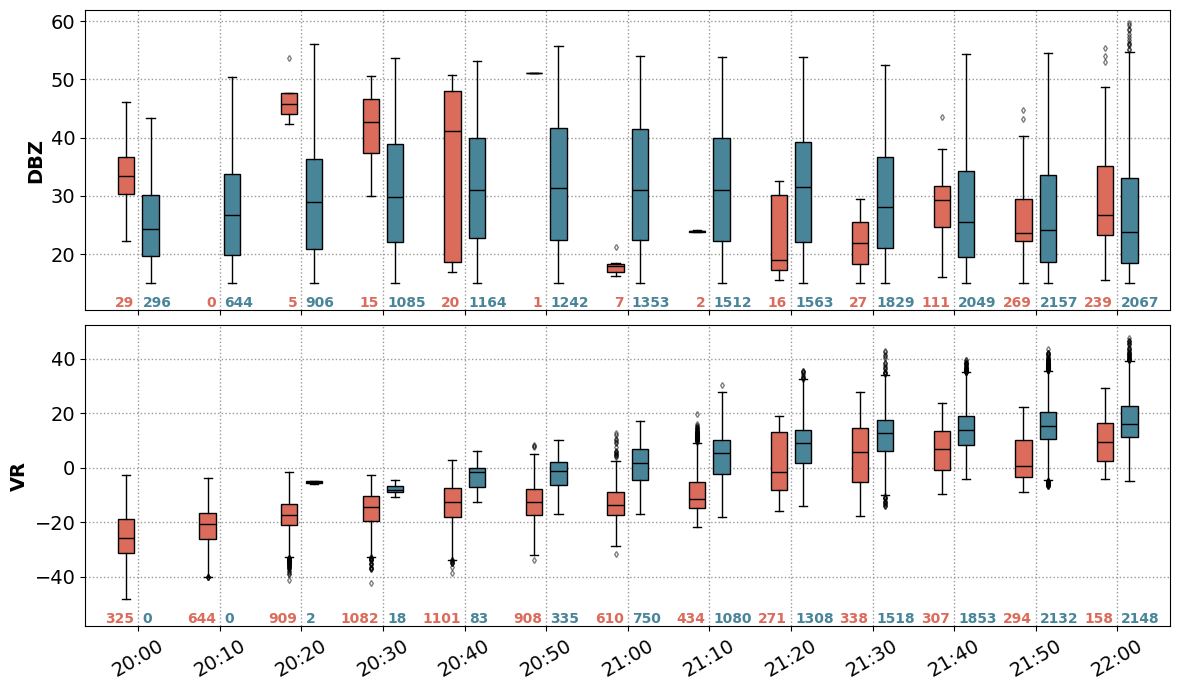

In [312]:
fig, axes = plt.subplots(2,1, figsize=(14, 8),sharex=True)

for ax, var in zip(axes, [ 'DBZ', 'VR']):

    keep_vals = []
    drop_vals = []
    
    for t in np.arange(13):
        sub = get_ds(ds, var, t)
     
        keep_vals.append(sub.value.values[sub.outlier <= 3])
        drop_vals.append(sub.value.values[sub.outlier > 3])
        
    num_keep = [len(v) for v in keep_vals]
    num_drop = [len(v) for v in drop_vals]

   

    offset=0.15
    pos1, pos2 = np.arange(len(keep_vals))+offset,np.arange(len(keep_vals))-offset
    
    draw_plot(ax,keep_vals, pos1,  'k', '#498599')
    draw_plot(ax, drop_vals, pos2, 'k', '#db6b5a')
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.05
    ax.set_ylim(y1-yoff, y2)
    
    y1, y2 = (ax.get_ylim())
    yoff = (y2-y1)*.01
    y = y1+yoff
    for x in np.arange(len(keep_vals)):
        ax.text(x-.05,y, num_drop[x], ha='right',weight='bold', color='#db6b5a')
        ax.text(x+.05,y, num_keep[x], ha='left', weight='bold', color='#498599')
    
    ax.set_xticks(np.arange(len(keep_vals)), [t.strftime('%H:%M') for t in times], rotation=30);
    ax.grid()

    ax.set_ylabel(var)

plt.subplots_adjust(hspace=0.05)


In [9]:



# figure out dimensions for arrays
ensN = exper['ne']
t    = len(file_list)


In [ ]:
# step one, make the 

In [107]:

values    = np.zeros([t,n])*np.nan
outlier   = np.zeros([t,n])*np.nan
var_stdev = np.zeros([t,n])*np.nan



Hxf    = np.zeros([t,n,ensN])*np.nan


In [111]:
np.shape(outlierL[0])


(5966,)

In [64]:
np.shape(kindL[0, kindL[0] == 11])

TypeError: list indices must be integers or slices, not tuple

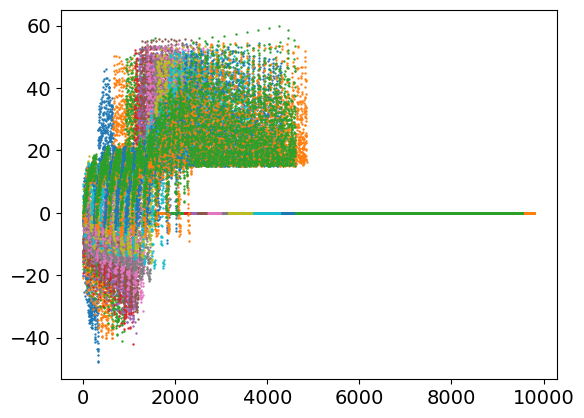

In [61]:
for i in range(allf):
    plt.scatter(range(len(values[i])), values[i], s=0.5)

In [42]:
values = np.zeros([len(file_list), size])*np.nan

In [47]:
for i in range(allf):
    valsize = len(valueL[i])
    values[i, :valsize] = valueL[i]

In [ ]:
size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [45]:

size = np.max([np.shape(valueL[i]) for i in range(allf)])

In [26]:
dirname = os.path.join(exps[1],_prior_files)
#plotfilename='DBZ_CR'
#noshow=True

bin_delta=1

file_list = glob.glob(dirname)
file_list = sorted(file_list,key=os.path.getmtime)

full=[]
fop = []
variable='REF0'

    #full.append( value[index] - Hxf[index,:] ) #hxfbar is the mean model values

for n, file in enumerate(file_list):

        f = ncdf.Dataset(file)

        if n % bin_delta == 0:
            HxfL,valueL,depL,errorL,secsL,zL,kindL = [],[],[],[],[],[],[]

        valueL.append(f.variables["value"][:])
        HxfL.append(f.variables["Hxf"][:]) #hxf is the model value at the location of that ob
        zL.append(f.variables["z"][:] - radar_hgt)
        depL.append( f.variables["value"][:] - f.variables["Hxfbar"][:] ) #hxfbar is the mean model values at that location
        secsL.append(f.variables["secs"][:])
        errorL.append(np.sqrt(f.variables["error"][:])) # error is the standard deviation
        kindL.append(ncdf.chartostring(f.variables["type"][:]))

        if n % bin_delta == bin_delta-1:
            Hxf   = np.concatenate(HxfL, axis=0)
            value = np.concatenate(valueL, axis=0)
            z     = np.concatenate(zL, axis=0)
            dep   = np.concatenate(depL, axis=0)
            secs  = np.concatenate(secsL, axis=0)
            error = np.concatenate(errorL, axis=0)
            kind  = np.concatenate(kindL, axis=0)
            #datebins.append(DT.datetime.utcfromtimestamp(secs.mean()))


            index_kind  = getIndexVariable(kind,variable)

            temp = (dep[index_kind][:])# - Hxf[index_kind,:])
            temp2 = Hxf[index_kind,:]
            if n == 0:
                full = temp.copy()
                fop = temp2.copy()
            else:
                full = np.concat([full, temp], axis=0)
                fop = np.concat([fop, temp2], axis=0)
            

In [351]:
exp = '/work/jessica.mcdonald/CM1_LETKF_2025/experiments/test_w'
ds = xr.open_dataset(f"{exp}/AllPrior_Post.nc", decode_timedelta=True)

var='DBZ0_W'

full = (get_var(ds,'value', var)[:,:,np.newaxis]-get_var(ds,'Hxf', var)).flatten()
full = full[np.isnan(full)==False]

In [ ]:
for i in r

In [354]:
bins

array([-38.19175564, -38.09175564, -37.99175564, -37.89175564,
       -37.79175564, -37.69175564, -37.59175564, -37.49175564,
       -37.39175564, -37.29175564, -37.19175564, -37.09175564,
       -36.99175564, -36.89175564, -36.79175564, -36.69175564,
       -36.59175564, -36.49175564, -36.39175564, -36.29175564,
       -36.19175564, -36.09175564, -35.99175564, -35.89175564,
       -35.79175564, -35.69175564, -35.59175564, -35.49175564,
       -35.39175564, -35.29175564, -35.19175564, -35.09175564,
       -34.99175564, -34.89175564, -34.79175564, -34.69175564,
       -34.59175564, -34.49175564, -34.39175564, -34.29175564,
       -34.19175564, -34.09175564, -33.99175564, -33.89175564,
       -33.79175564, -33.69175564, -33.59175564, -33.49175564,
       -33.39175564, -33.29175564, -33.19175564, -33.09175564,
       -32.99175564, -32.89175564, -32.79175564, -32.69175564,
       -32.59175564, -32.49175564, -32.39175564, -32.29175564,
       -32.19175564, -32.09175564, -31.99175564, -31.89

[     1      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      1      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      0      0
      0      0      0      0      0      0      0      0      1      0
      

(-5.0, 0.1)

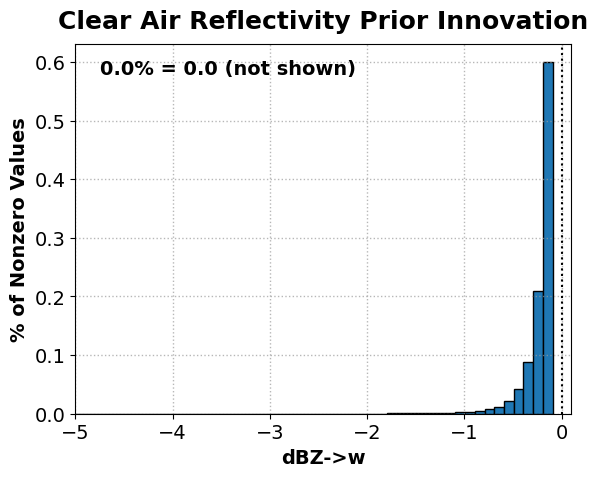

In [353]:
eqzero = 100*list(full.flatten()).count(0.0)/len(full.flatten())

width = .1
bins = np.arange(np.min(full), 0, width)
counts, bin_edges  = np.histogram(full.flatten(), bins=bins)
#ncounts, nbin_edges  = np.histogram(full.flatten(), bins=bins)

print(counts)

print(sum(counts))
#print(sum(ncounts))

bin_c= (bin_edges[:-1] + bin_edges[1:]) / 2
#nbin_c = (nbin_edges[:-1] + nbin_edges[1:]) / 2

fig=plt.figure()
plt.title('Clear Air Reflectivity Prior Innovation', weight='bold', y=1.02)
plt.bar(bin_c, counts/sum(counts), width=width, edgecolor='k')

plt.text(0.05, .96, f"{eqzero:.1f}% = 0.0 (not shown)",va='top', fontsize=14, weight='bold', transform=plt.gca().transAxes)

plt.xlabel('dBZ->w')
plt.ylabel('% of Nonzero Values')
plt.axvline(0, color='k', ls=':')
plt.grid(ls=":", alpha=0.7)

plt.xlim(-5, .1)

/tmp/ipykernel_1466515/2940125403.py:33: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))


Text(0.5, 0, 'Time (UTC)')

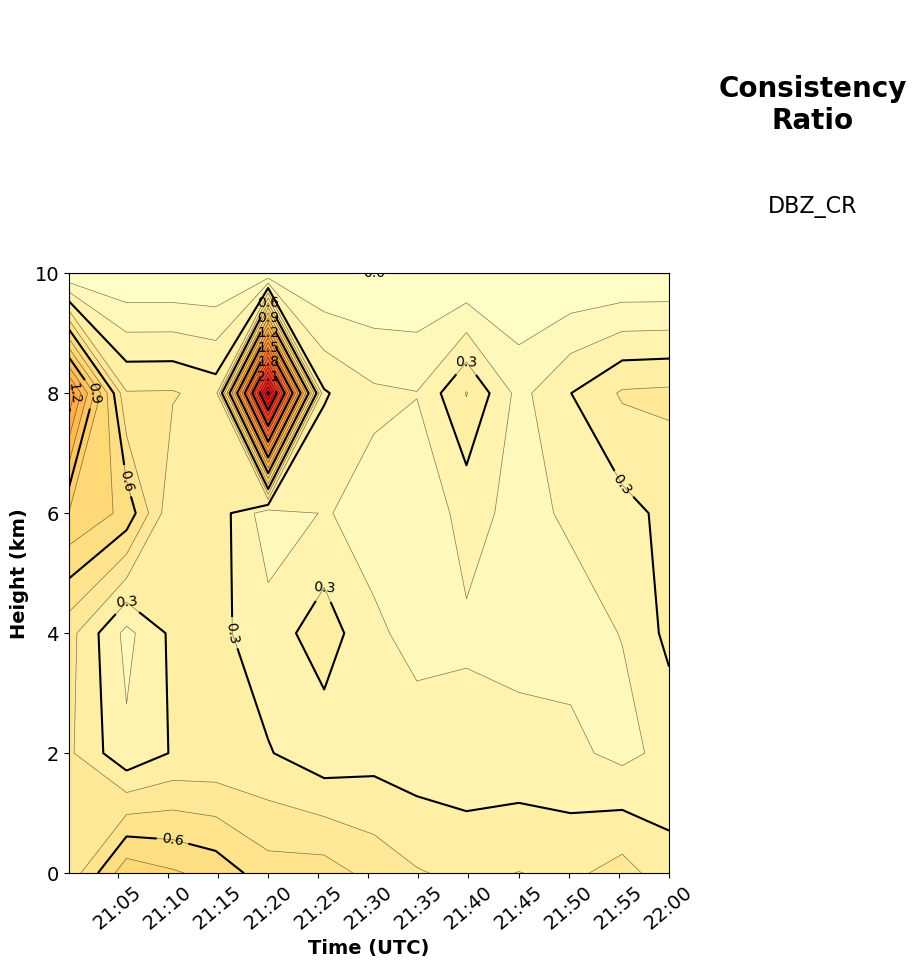

In [5]:
_cmin, _cmax = 0.0, 1.1   # limits for the single line plots...

variable = "VR"   # valid variables:  VR, DBZ
variable = 11   # valid variables:  VR, DBZ

sec_utime = "seconds since 1970-01-01 00:00:00"
auto_clevels = True

# definitions for the plot layout with multiple panels
left, width = 0.1, 0.5
bottom, height = 0.1, 0.5
bottom_h = left_h = left+width+0.03

rectC = [left, bottom, width, height]
rectX = [left, bottom_h, width, 0.2]
rectY = [left_h, bottom, 0.2, height]

fig = P.figure(figsize=(12,12))
fig.text(0.72, 0.72, "\n\nConsistency\nRatio", size=20, va="baseline", ha="center", multialignment="center", weight='bold')
fig.text(0.72, 0.65, plotfilename, size=16, va="baseline", ha="center", multialignment="center")


axC = P.axes(rectC)

zmin, zmax, cint = nice_mxmnintvl(zbins.min()/1000., zbins.max()/1000., outside=True, cint=1.0)
zmin = 0.0

if auto_clevels:
    cmin, cmax, cint, clevels = nice_clevels(0, 3, outside=False, cint = 0.1)
else:
    clevels = np.arange(spread_limits[0], spread_limits[1], spread_limits[2])

cs1=axC.contourf(datebins, zbins/1000., CR_TZ, clevels, cmap=cm.get_cmap('YlOrRd'))
axC.contour(datebins,  zbins/1000., CR_TZ, clevels, colors='k', linewidths=0.5, alpha=0.5)
cs2=axC.contour(datebins,  zbins/1000., CR_TZ, cs1.levels[::3], colors='k')

start = datebins[0]
end   = datebins[-1]

nticks_approx = 8
minute_interval = 5*round((end-start).seconds/(nticks_approx*60*5)) #find the best interval divisble by 5 based on nticks

axC.set_xlim(start, end)
axC.set_ylim(zmin,zmax)

maj_loc = mdates.MinuteLocator(interval=minute_interval)
axC.xaxis.set_major_locator(maj_loc)
dateFmt = mdates.DateFormatter('%H:%M')
axC.xaxis.set_major_formatter(dateFmt)

labels = axC.get_xticklabels()
P.setp(labels, rotation=40, fontsize=14)

axC.clabel(cs2, inline=1, fontsize=10, fmt="%1.1f")
axC.set_ylabel("Height (km)", weight='bold')
axC.set_xlabel("Time (UTC)",weight='bold')

# ens stuff